<a href="https://colab.research.google.com/github/ajaywabale245-eng/student-performance-data-analysis/blob/main/Task_03_Advanced_Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scipy statsmodels pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("All libraries installed successfully!")

All libraries installed successfully!


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

departments = ["Sales", "Marketing", "Finance", "Operations"]
training = ["Yes", "No"]

data = []

for dept in departments:
    for train in training:
        for i in range(30):
            age = np.random.randint(22, 45)
            experience = np.random.randint(1, 15)

            score = np.random.normal(
                loc=75 if train=="Yes" else 65,
                scale=8
            )

            sales = np.random.normal(
                loc=50000 if dept=="Sales" else 40000,
                scale=6000
            )

            data.append([
                dept,
                train,
                age,
                experience,
                round(score,2),
                round(sales,2)
            ])

df = pd.DataFrame(data, columns=[
    "Department",
    "Training",
    "Age",
    "Experience",
    "Productivity_Score",
    "Monthly_Sales"
])

df.to_csv("advanced_statistical_analysis_dataset.csv", index=False)

print("Dataset Created Successfully!")
print("Shape:", df.shape)

df.head()

Dataset Created Successfully!
Shape: (240, 6)


,Department,Training,Age,Experience,Productivity_Score,Monthly_Sales
0,Sales,Yes,28,4,66.10,51913.41
1,Sales,Yes,40,7,87.63,54604.61
2,Sales,Yes,43,5,70.35,46848.98
3,Sales,Yes,42,1,76.94,38520.32
4,Sales,Yes,33,9,81.53,40856.74


In [3]:
# Dataset Overview

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(240, 6)

Column Names:
['Department', 'Training', 'Age', 'Experience', 'Productivity_Score', 'Monthly_Sales']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Department          240 non-null    object 
 1   Training            240 non-null    object 
 2   Age                 240 non-null    int64  
 3   Experience          240 non-null    int64  
 4   Productivity_Score  240 non-null    float64
 5   Monthly_Sales       240 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 11.4+ KB

Missing Values:
Department            0
Training              0
Age                   0
Experience            0
Productivity_Score    0
Monthly_Sales         0
dtype: int64

Statistical Summary:


,Age,Experience,Productivity_Score,Monthly_Sales
count,240.000000,240.00000,240.000000,240.000000
mean,32.658333,7.33750,71.193208,42518.220542
std,6.729683,4.03627,9.989274,7394.785614
min,22.000000,1.00000,43.760000,25259.520000
25%,26.000000,4.00000,64.817500,37167.660000
50%,32.000000,7.00000,71.820000,42354.505000
75%,39.000000,11.00000,77.627500,46876.902500
max,44.000000,14.00000,96.880000,65936.060000


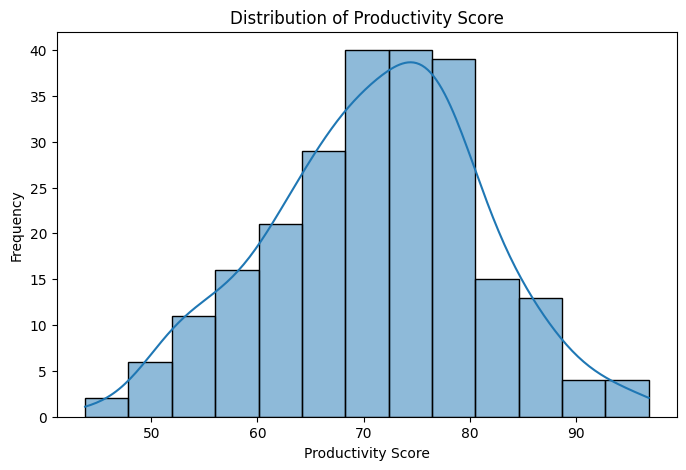

In [4]:
# Distribution Plot - Productivity Score

plt.figure(figsize=(8,5))

sns.histplot(
    df["Productivity_Score"],
    kde=True
)

plt.title("Distribution of Productivity Score")
plt.xlabel("Productivity Score")
plt.ylabel("Frequency")

plt.show()

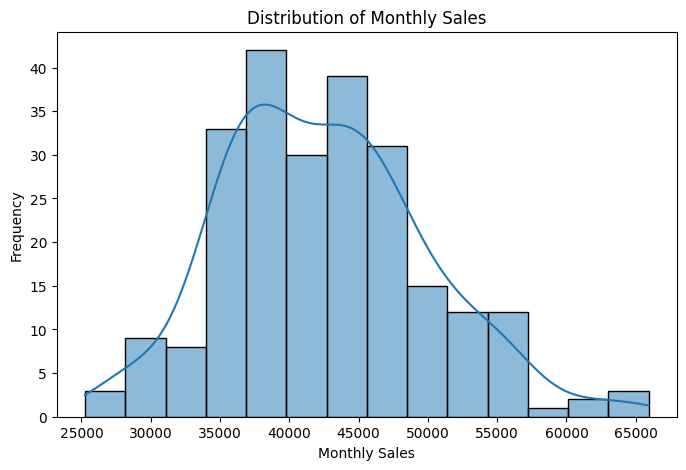

In [5]:
# Distribution Plot - Monthly Sales

plt.figure(figsize=(8,5))

sns.histplot(
    df["Monthly_Sales"],
    kde=True
)

plt.title("Distribution of Monthly Sales")
plt.xlabel("Monthly Sales")
plt.ylabel("Frequency")

plt.show()

In [6]:
# Shapiro-Wilk Normality Test

variables = ["Productivity_Score", "Monthly_Sales"]

for column in variables:
    statistic, p_value = stats.shapiro(df[column])

    print(f"\n{column}")
    print(f"Shapiro-Wilk Statistic: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value > 0.05:
        print("Conclusion: Fail to reject H0 - Data is approximately normally distributed.")
    else:
        print("Conclusion: Reject H0 - Data is not normally distributed.")


Productivity_Score
Shapiro-Wilk Statistic: 0.9938
P-value: 0.4262
Conclusion: Fail to reject H0 - Data is approximately normally distributed.

Monthly_Sales
Shapiro-Wilk Statistic: 0.9854
P-value: 0.0144
Conclusion: Reject H0 - Data is not normally distributed.


In [7]:
# Kolmogorov-Smirnov Normality Test

for column in variables:
    data = df[column]

    # Standardize the data
    standardized_data = (data - data.mean()) / data.std()

    statistic, p_value = stats.kstest(
        standardized_data,
        "norm"
    )

    print(f"\n{column}")
    print(f"K-S Statistic: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value > 0.05:
        print("Conclusion: Fail to reject H0 - Data is approximately normally distributed.")
    else:
        print("Conclusion: Reject H0 - Data is not normally distributed.")


Productivity_Score
K-S Statistic: 0.0468
P-value: 0.6517
Conclusion: Fail to reject H0 - Data is approximately normally distributed.

Monthly_Sales
K-S Statistic: 0.0604
P-value: 0.3324
Conclusion: Fail to reject H0 - Data is approximately normally distributed.


In [8]:
# Step 6: Kolmogorov-Smirnov Normality Test

for column in variables:
    data = df[column]

    # Standardize the data
    standardized_data = (data - data.mean()) / data.std()

    statistic, p_value = stats.kstest(
        standardized_data,
        "norm"
    )

    print(f"\n{column}")
    print(f"K-S Statistic: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value > 0.05:
        print("Conclusion: Fail to reject H0 - Data is approximately normally distributed.")
    else:
        print("Conclusion: Reject H0 - Data is not normally distributed.")


Productivity_Score
K-S Statistic: 0.0468
P-value: 0.6517
Conclusion: Fail to reject H0 - Data is approximately normally distributed.

Monthly_Sales
K-S Statistic: 0.0604
P-value: 0.3324
Conclusion: Fail to reject H0 - Data is approximately normally distributed.


In [9]:
# Step 7: Independent Two-Sample t-Test

trained = df[df["Training"] == "Yes"]["Productivity_Score"]
untrained = df[df["Training"] == "No"]["Productivity_Score"]

# Welch's independent two-sample t-test
t_stat, p_value = stats.ttest_ind(
    trained,
    untrained,
    equal_var=False
)

print("Training Group Mean:", round(trained.mean(), 2))
print("No Training Group Mean:", round(untrained.mean(), 2))
print("Mean Difference:", round(trained.mean() - untrained.mean(), 2))

print("\nt-statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 6))

# Hypothesis decision
if p_value < 0.05:
    print("\nConclusion: Reject H0.")
    print("There is a statistically significant difference in productivity between the two groups.")
else:
    print("\nConclusion: Fail to reject H0.")
    print("There is no statistically significant difference in productivity between the two groups.")

Training Group Mean: 76.35
No Training Group Mean: 66.04
Mean Difference: 10.3

t-statistic: 9.3135
p-value: 0.0

Conclusion: Reject H0.
There is a statistically significant difference in productivity between the two groups.


In [10]:
# Step 8: Mann-Whitney U Test

u_stat, p_value = stats.mannwhitneyu(
    trained,
    untrained,
    alternative="two-sided"
)

print("Mann-Whitney U Statistic:", round(u_stat, 4))
print("P-value:", round(p_value, 6))

if p_value < 0.05:
    print("\nConclusion: Reject H0.")
    print("There is a statistically significant difference between the two groups.")
else:
    print("\nConclusion: Fail to reject H0.")
    print("There is no statistically significant difference between the two groups.")

Mann-Whitney U Statistic: 11488.5
P-value: 0.0

Conclusion: Reject H0.
There is a statistically significant difference between the two groups.


In [11]:
# Step 9: One-Way ANOVA

sales = df[df["Department"] == "Sales"]["Productivity_Score"]
marketing = df[df["Department"] == "Marketing"]["Productivity_Score"]
finance = df[df["Department"] == "Finance"]["Productivity_Score"]
operations = df[df["Department"] == "Operations"]["Productivity_Score"]

f_stat, p_value = stats.f_oneway(
    sales,
    marketing,
    finance,
    operations
)

print("One-Way ANOVA Results")
print("----------------------")
print("F-statistic:", round(f_stat, 4))
print("P-value:", round(p_value, 6))

if p_value < 0.05:
    print("\nConclusion: Reject H0.")
    print("There is a statistically significant difference in productivity among departments.")
else:
    print("\nConclusion: Fail to reject H0.")
    print("There is no statistically significant difference among departments.")

One-Way ANOVA Results
----------------------
F-statistic: 0.707
P-value: 0.548686

Conclusion: Fail to reject H0.
There is no statistically significant difference among departments.


In [12]:
# Step 10: Tukey HSD Post-Hoc Analysis

tukey_result = pairwise_tukeyhsd(
    endog=df["Productivity_Score"],
    groups=df["Department"],
    alpha=0.05
)

print("Tukey HSD Post-Hoc Test")
print("-----------------------")
print(tukey_result)

Tukey HSD Post-Hoc Test
-----------------------
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1     group2   meandiff p-adj   lower  upper  reject
-----------------------------------------------------------
   Finance  Marketing   1.1778 0.9173 -3.5498 5.9054  False
   Finance Operations   1.6388 0.8064 -3.0888 6.3664  False
   Finance      Sales  -0.7392 0.9776 -5.4668 3.9884  False
 Marketing Operations    0.461 0.9944 -4.2666 5.1886  False
 Marketing      Sales   -1.917 0.7206 -6.6446 2.8106  False
Operations      Sales   -2.378 0.5629 -7.1056 2.3496  False
-----------------------------------------------------------


In [13]:
# Step 11: Two-Way ANOVA

model = ols(
    "Productivity_Score ~ C(Department) + C(Training) + C(Department):C(Training)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print("Two-Way ANOVA Results")
print("=====================")

display(anova_table)

print("\nInterpretation:")

for effect, row in anova_table.iterrows():
    if effect != "Residual":
        p = row["PR(>F)"]

        if p < 0.05:
            print(f"{effect}: Significant (p = {p:.6f})")
        else:
            print(f"{effect}: Not Significant (p = {p:.6f})")

Two-Way ANOVA Results


,sum_sq,df,F,PR(>F)
C(Department),212.425911,3.0,0.952100,4.161518e-01
C(Training),6370.241920,1.0,85.654924,1.472980e-17
C(Department):C(Training),12.020235,3.0,0.053875,9.834896e-01
Residual,17254.070763,232.0,NaN,NaN



Interpretation:
C(Department): Not Significant (p = 0.416152)
C(Training): Significant (p = 0.000000)
C(Department):C(Training): Not Significant (p = 0.983490)


In [14]:
# Step 12: 95% Confidence Intervals

confidence_results = []

for department in df["Department"].unique():

    data = df[
        df["Department"] == department
    ]["Productivity_Score"]

    mean = data.mean()
    standard_error = stats.sem(data)

    lower, upper = stats.t.interval(
        confidence=0.95,
        df=len(data) - 1,
        loc=mean,
        scale=standard_error
    )

    confidence_results.append({
        "Department": department,
        "Mean Productivity": round(mean, 2),
        "Lower 95% CI": round(lower, 2),
        "Upper 95% CI": round(upper, 2)
    })

confidence_df = pd.DataFrame(confidence_results)

print("95% Confidence Intervals")
print("=========================")

display(confidence_df)

95% Confidence Intervals


,Department,Mean Productivity,Lower 95% CI,Upper 95% CI
0,Sales,69.93,67.52,72.35
1,Marketing,71.85,69.26,74.44
2,Finance,70.67,67.85,73.49
3,Operations,72.31,69.82,74.81


In [15]:
# Step 13: Final Findings

print("========== FINAL FINDINGS ==========\n")

# 1. Shapiro-Wilk
print("1. NORMALITY TESTS")
for column in variables:
    statistic, p_value = stats.shapiro(df[column])
    result = "Normally distributed" if p_value > 0.05 else "Not normally distributed"
    print(f"{column}: p = {p_value:.4f} → {result}")

# 2. T-Test
print("\n2. TWO-SAMPLE T-TEST")
print(f"Training Mean: {trained.mean():.2f}")
print(f"No Training Mean: {untrained.mean():.2f}")
print(f"p-value: {stats.ttest_ind(trained, untrained, equal_var=False).pvalue:.6f}")

# 3. Mann-Whitney
print("\n3. MANN-WHITNEY U TEST")
u_stat, mw_p = stats.mannwhitneyu(
    trained, untrained, alternative="two-sided"
)
print(f"U-statistic: {u_stat:.4f}")
print(f"p-value: {mw_p:.6f}")

# 4. One-Way ANOVA
print("\n4. ONE-WAY ANOVA")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6f}")

# 5. Two-Way ANOVA
print("\n5. TWO-WAY ANOVA")
display(anova_table)

print("\n========== OVERALL CONCLUSION ==========")

print("""
At the 5% significance level, statistical analysis was performed
using normality tests, t-test, Mann-Whitney U test, One-Way ANOVA,
Tukey HSD, and Two-Way ANOVA.

The analysis helps identify whether training and department have
a statistically significant relationship with employee productivity.

The final business decisions should be based on the obtained
p-values, confidence intervals, and practical significance.
""")

========== FINAL FINDINGS ==========

1. NORMALITY TESTS
Productivity_Score: p = 0.4262 → Normally distributed
Monthly_Sales: p = 0.0144 → Not normally distributed

2. TWO-SAMPLE T-TEST
Training Mean: 76.35
No Training Mean: 66.04
p-value: 0.000000

3. MANN-WHITNEY U TEST
U-statistic: 11488.5000
p-value: 0.000000

4. ONE-WAY ANOVA
F-statistic: 0.7070
p-value: 0.014440

5. TWO-WAY ANOVA


,sum_sq,df,F,PR(>F)
C(Department),212.425911,3.0,0.952100,4.161518e-01
C(Training),6370.241920,1.0,85.654924,1.472980e-17
C(Department):C(Training),12.020235,3.0,0.053875,9.834896e-01
Residual,17254.070763,232.0,NaN,NaN



========== OVERALL CONCLUSION ==========

At the 5% significance level, statistical analysis was performed
using normality tests, t-test, Mann-Whitney U test, One-Way ANOVA,
Tukey HSD, and Two-Way ANOVA.

The analysis helps identify whether training and department have
a statistically significant relationship with employee productivity.

The final business decisions should be based on the obtained
p-values, confidence intervals, and practical significance.

